# CausalPype — Framingham Heart Study Demo

*What are the causal determinants of 10-year coronary heart disease (CHD) risk?*

This notebook walks the entire CausalPype API on the Framingham cohort (4,240 participants × 16 cardiovascular risk factors) and is the reference example for the SETN2026 paper. **Every analytical step below is a single CausalPype call** — no hand-rolled matplotlib, no manual result formatting. The point is to show that the same analyses that take dozens of imperative DoWhy / EconML calls collapse to one declarative line each.

## 1. Setup

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, IterativeImputer

import causalpype as cp

FIGDIR = Path('figures'); FIGDIR.mkdir(exist_ok=True)

## 2. Data

Load the Framingham CSV. Categorical columns are mode-imputed; continuous columns use MICE (sklearn). This is the only non-CausalPype work in the notebook.

In [2]:
df = pd.read_csv('data/framingham.csv')

cat_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
cont_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

df[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[cat_cols])

df_mice = df.copy()
for c in cat_cols:
    df_mice[c] = df_mice[c].astype(float)
imputed = pd.DataFrame(
    IterativeImputer(max_iter=20, random_state=42).fit_transform(df_mice),
    columns=df_mice.columns, index=df_mice.index,
)
for c in cont_cols:
    df[c] = imputed[c]

clip = dict(cigsPerDay=(0, 70), totChol=(100, 600), sysBP=(80, 300),
            diaBP=(40, 200), BMI=(10, 60), heartRate=(30, 220), glucose=(40, 500))
for col, (lo, hi) in clip.items():
    df[col] = df[col].clip(lo, hi)

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1.0,39.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0.0,46.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1.0,48.0,1.0,1.0,20.0,0.0,0.0,0.0,0.0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0.0,61.0,3.0,1.0,30.0,0.0,0.0,1.0,0.0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0.0,46.0,3.0,1.0,23.0,0.0,0.0,0.0,0.0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 3. Causal graph and model fit

The DAG is a domain-knowledge encoding of cardiovascular risk factors. CausalPype accepts a plain adjacency dict, builds the structural causal model, auto-assigns mechanisms, and fits in one call.

In [3]:
dag = {
    'age':             ['sysBP', 'diaBP', 'totChol', 'glucose', 'BMI', 'heartRate', 'TenYearCHD'],
    'male':            ['sysBP', 'diaBP', 'totChol', 'BMI', 'heartRate', 'currentSmoker', 'TenYearCHD'],
    'education':       ['currentSmoker'],
    'currentSmoker':   ['cigsPerDay'],
    'cigsPerDay':      ['heartRate', 'TenYearCHD'],
    'BMI':             ['sysBP', 'diaBP', 'totChol', 'glucose', 'diabetes', 'TenYearCHD'],
    'sysBP':           ['prevalentHyp', 'TenYearCHD'],
    'diaBP':           ['prevalentHyp'],
    'prevalentHyp':    ['BPMeds'],
    'glucose':         ['diabetes'],
    'diabetes':        ['TenYearCHD'],
    'totChol':         ['TenYearCHD'],
    'heartRate':       ['TenYearCHD'],
    'prevalentStroke': ['TenYearCHD'],
}

model = cp.CausalModel(dag, assignment_quality='better')
model.fit(df)

Fitting causal models:   0%|          | 0/16 [00:00<?, ?it/s]

Fitting causal mechanism of node age:   0%|          | 0/16 [00:00<?, ?it/s]

Fitting causal mechanism of node male:   0%|          | 0/16 [00:00<?, ?it/s]

Fitting causal mechanism of node education:   0%|          | 0/16 [00:00<?, ?it/s]

Fitting causal mechanism of node currentSmoker:   0%|          | 0/16 [00:00<?, ?it/s]

...

Fitting causal mechanism of node prevalentStroke:  88%|████████▊ | 14/16 [00:00<00:00, 36.02it/s]

Fitting causal mechanism of node TenYearCHD:  88%|████████▊ | 14/16 [00:00<00:00, 36.02it/s]     

Fitting causal mechanism of node BPMeds:  88%|████████▊ | 14/16 [00:00<00:00, 36.02it/s]    

Fitting causal mechanism of node BPMeds: 100%|██████████| 16/16 [00:00<00:00, 43.66it/s]

CausalModel(fitted, nodes=['age', 'male', 'education', 'currentSmoker', 'cigsPerDay', 'BMI', 'sysBP', 'diaBP', 'prevalentHyp', 'glucose', 'diabetes', 'totChol', 'heartRate', 'prevalentStroke', 'TenYearCHD', 'BPMeds'], edges=[('age', 'sysBP'), ('age', 'diaBP'), ('age', 'totChol'), ('age', 'glucose'), ('age', 'BMI'), ('age', 'heartRate'), ('age', 'TenYearCHD'), ('male', 'sysBP'), ('male', 'diaBP'), ('male', 'totChol'), ('male', 'BMI'), ('male', 'heartRate'), ('male', 'currentSmoker'), ('male', 'TenYearCHD'), ('education', 'currentSmoker'), ('currentSmoker', 'cigsPerDay'), ('cigsPerDay', 'heartRate'), ('cigsPerDay', 'TenYearCHD'), ('BMI', 'sysBP'), ('BMI', 'diaBP'), ('BMI', 'totChol'), ('BMI', 'glucose'), ('BMI', 'diabetes'), ('BMI', 'TenYearCHD'), ('sysBP', 'prevalentHyp'), ('sysBP', 'TenYearCHD'), ('diaBP', 'prevalentHyp'), ('prevalentHyp', 'BPMeds'), ('glucose', 'diabetes'), ('diabetes', 'TenYearCHD'), ('totChol', 'TenYearCHD'), ('heartRate', 'TenYearCHD'), ('prevalentStroke', 'TenYear

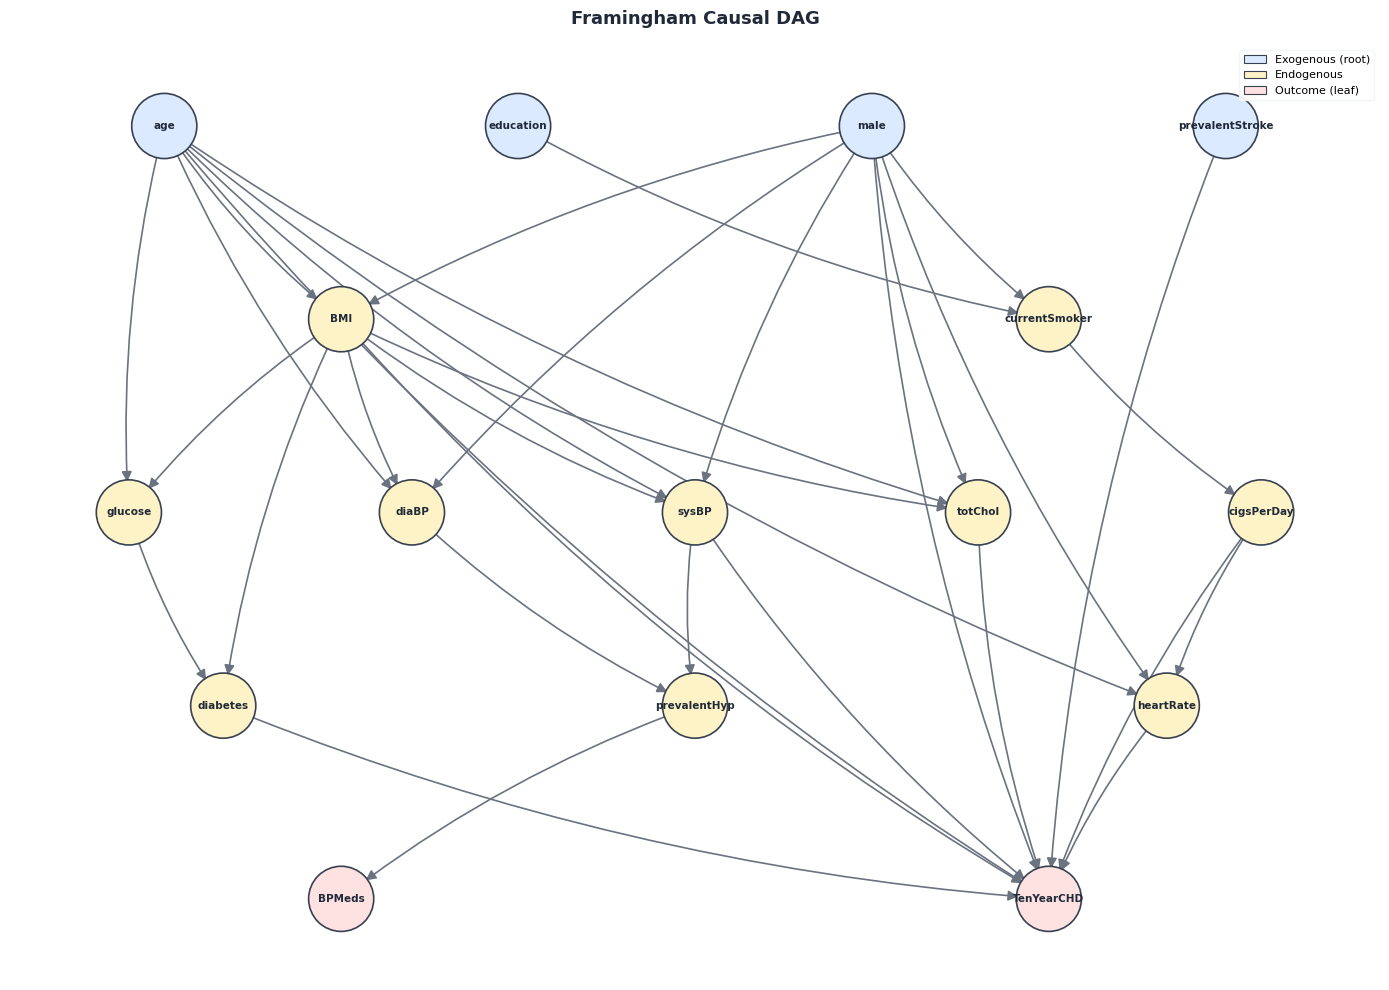

In [4]:
fig, _ = cp.plotting.plot_graph(model, title='Framingham Causal DAG')
fig.savefig(FIGDIR / 'dag.pdf')

## 4. Validate the SCM assumptions

`Validate` runs DoWhy's structural and invertible-model refutations and applies a Bonferroni correction across all conditional-independence tests.

In [5]:
model.run(cp.Validate(method='all'))

                    Validation Results                    
 Result                                       ISSUES FOUND
----------------------------------------------------------
 Structure Validation
    Passed                                              No
    N Tests                                             45
    Bonferroni Level                                0.0011
   Failed edges:
     education -> currentSmoker (p=0.3499)
     male -> sysBP (p=0.2705)
     age -> heartRate (p=0.1598)
     cigsPerDay -> heartRate (p=0.1528)
     heartRate -> TenYearCHD (p=0.2118)
     prevalentStroke -> TenYearCHD (p=0.0952)
----------------------------------------------------------
 Model Validation
    Passed                                              No
    Result                                        REJECTED

## 5. Mechanistic drivers

`ArrowStrength` quantifies how much each direct parent contributes to `TenYearCHD`. `IntrinsicCausalInfluence` decomposes the target's variance across the *entire* upstream graph (Shapley values). Both run in one batched call.

In [6]:
r_arrow, r_ici = model.run([
    cp.ArrowStrength(target='TenYearCHD'),
    cp.IntrinsicCausalInfluence(target='TenYearCHD'),
])
r_arrow

Evaluating set functions...:   0%|          | 0/267 [00:00<?, ?it/s]

Evaluating set functions...:  12%|█▏        | 32/267 [00:01<00:09, 25.32it/s]

Evaluating set functions...:  18%|█▊        | 48/267 [00:02<00:12, 17.92it/s]

Evaluating set functions...:  24%|██▍       | 64/267 [00:03<00:13, 15.38it/s]

Evaluating set functions...:  30%|██▉       | 80/267 [00:05<00:13, 14.26it/s]

...

Evaluating set functions...:  84%|████████▍ | 224/267 [00:16<00:03, 12.55it/s]

Evaluating set functions...:  90%|████████▉ | 240/267 [00:17<00:02, 12.45it/s]

Evaluating set functions...:  96%|█████████▌| 256/267 [00:19<00:00, 12.46it/s]

Evaluating set functions...: 100%|██████████| 267/267 [00:19<00:00, 13.88it/s]

                  Arrow Strength Results                  
 Target                                         TenYearCHD
----------------------------------------------------------
  sysBP -> TenYearCHD                               0.0035
  male -> TenYearCHD                                0.0021
  prevalentStroke -> TenYearCHD                     0.0016
  age -> TenYearCHD                                 0.0015
  BMI -> TenYearCHD                                 0.0011
  cigsPerDay -> TenYearCHD                          0.0009
  heartRate -> TenYearCHD                           0.0007
  totChol -> TenYearCHD                            -0.0006
  diabetes -> TenYearCHD                            0.0004

In [7]:
r_ici

            Intrinsic Causal Influence Results            
 Target                                         TenYearCHD
 Total Variance Explained                           0.1283
----------------------------------------------------------
  TenYearCHD (99.3%)                                0.1274
  prevalentStroke (0.3%)                            0.0004
  age (0.2%)                                        0.0002
  sysBP (0.1%)                                      0.0001
  male (0.1%)                                       0.0001
  diabetes (0.1%)                                   0.0001
  glucose (-0.1%)                                  -0.0001
  totChol (-0.0%)                                  -0.0000
  heartRate (0.0%)                                  0.0000
  cigsPerDay (-0.0%)                               -0.0000
  education (0.0%)                                  0.0000
  BMI (0.0%)                                        0.0000
  currentSmoker (0.0%)                              0.00

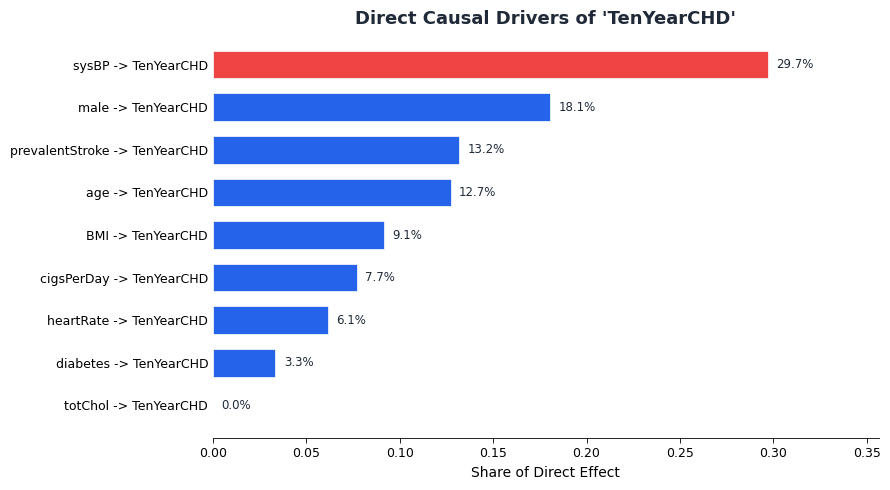

In [8]:
fig, _ = cp.plotting.plot_arrow_strength(r_arrow, normalize=True)
fig.savefig(FIGDIR / 'arrow_strength.pdf')

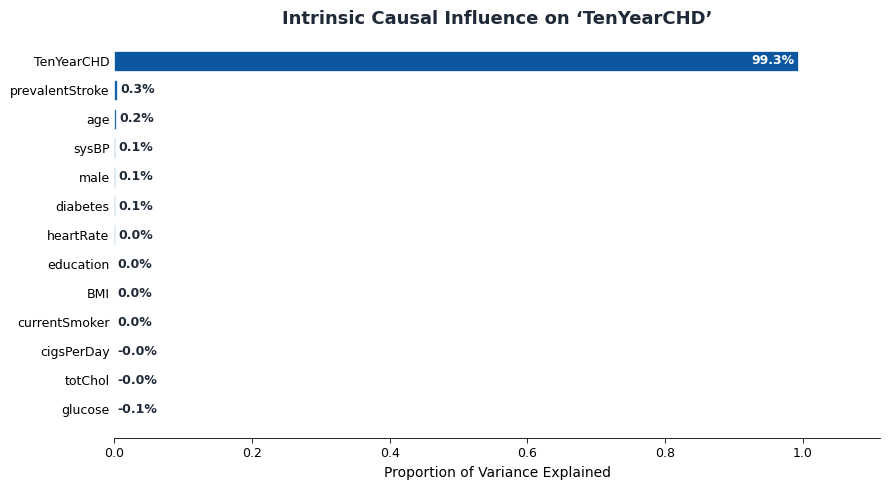

In [9]:
fig, _ = cp.plotting.plot_influences(r_ici)
fig.savefig(FIGDIR / 'influences.pdf')

## 6. Average treatment effects

Three binary treatments compared in a single batched call — smoking, blood pressure medication, diabetes — plus a model-free matching estimate (`KNNIntervention`) for the smoking effect as a sanity check.

                       ATE Results                        
 Treatment                                   currentSmoker
 Outcome                                        TenYearCHD
 Treatment Value                                         1
 Control Value                                           0
----------------------------------------------------------
 Estimate                                          -0.0027
 Num Samples                                         3,000

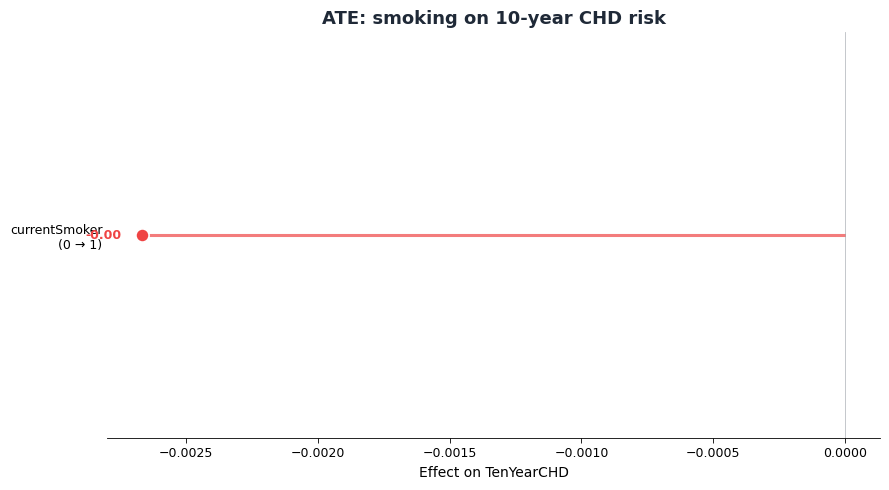

In [10]:
r_ate = model.run(cp.ATE(treatment='currentSmoker', outcome='TenYearCHD', num_samples=3000))
fig, _ = cp.plotting.plot_effects([r_ate], title='ATE: smoking on 10-year CHD risk')
fig.savefig(FIGDIR / 'ate.pdf')
r_ate

In [11]:
model.run(cp.KNNIntervention(
    treatment='currentSmoker', outcome='TenYearCHD', k=5,
    match_on=['age', 'male', 'sysBP', 'diaBP', 'BMI', 'totChol'],
))

                 KNN Intervention Results                 
 Treatment                                   currentSmoker
 Outcome                                        TenYearCHD
 K                                                       5
 N Treated                                           2,095
 N Control                                           2,145
----------------------------------------------------------
 ATE                                                0.0384
 ATT                                                0.0498
 ATC                                                0.0272
 Std ITE                                            0.3795
----------------------------------------------------------
 Match Quality (Treated)                            0.7267
 Match Quality (Control)                            0.7866

## 7. Heterogeneous treatment effects (CATE)

Two estimators in one batch: a `causal_forest` (which uses the auto-detected adjustment set as nuisance controls) and a `metalearner` T-learner (modifier-only). The plot shows the distribution of individual smoking effects across the cohort.

In [12]:
r_cate_forest, r_cate_meta = model.run([
    cp.CATE(treatment='currentSmoker', outcome='TenYearCHD',
            effect_modifiers=['age', 'male', 'sysBP'],
            method='causal_forest', n_estimators=200, random_state=42),
    cp.CATE(treatment='currentSmoker', outcome='TenYearCHD',
            effect_modifiers=['age', 'male', 'sysBP'],
            method='metalearner'),
])
r_cate_forest

                       CATE Results                       
 Treatment                                   currentSmoker
 Outcome                                        TenYearCHD
 Effect Modifiers                         age, male, sysBP
 Method                                      causal_forest
----------------------------------------------------------
 Mean Effect                                        0.0408
 Std Effect                                         0.0657
 Bounds                                  [-0.2127, 0.2973]

In [13]:
r_cate_meta

                       CATE Results                       
 Treatment                                   currentSmoker
 Outcome                                        TenYearCHD
 Effect Modifiers                         age, male, sysBP
 Method                                        metalearner
----------------------------------------------------------
 Mean Effect                                        0.0376
 Std Effect                                         0.1085
 Bounds                                  [-1.1446, 0.8840]

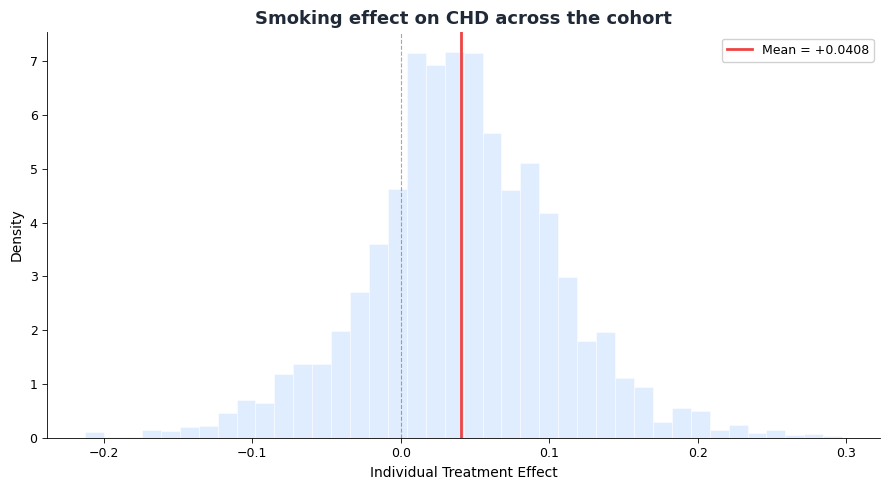

In [14]:
fig, _ = cp.plotting.plot_cate_distribution(r_cate_forest, title='Smoking effect on CHD across the cohort')
fig.savefig(FIGDIR / 'cate.pdf')

## 8. Hypothetical worlds

Three different intervention types in one batch:

- **`Intervention`** — hard `do(sysBP=v)` at a normal vs hypertensive value
- **`StochasticIntervention`** — a population-wide −10 mmHg shift in BP
- **`Counterfactual`** — individual-level retrospective: heavy smokers who developed CHD, *had they never smoked*

In [15]:
heavy_chd = df[(df['cigsPerDay'] > 20) & (df['TenYearCHD'] == 1)]

r_low, r_high, r_stoch, r_cf = model.run([
    cp.Intervention(interventions={'sysBP': 115.0}, outcome='TenYearCHD', num_samples=3000),
    cp.Intervention(interventions={'sysBP': 140.0}, outcome='TenYearCHD', num_samples=3000),
    cp.StochasticIntervention(treatment='sysBP', outcome='TenYearCHD', shift=-10.0, num_samples=3000),
    cp.Counterfactual(interventions={'currentSmoker': 0, 'cigsPerDay': 0.0},
                      observed_data=heavy_chd, outcome='TenYearCHD'),
])
r_low

                   Intervention Results                   
 Interventions                              sysBP := 115.0
 Outcome                                        TenYearCHD
----------------------------------------------------------
 Mean                                               0.1343
 Std                                                0.3498

In [16]:
r_high

                   Intervention Results                   
 Interventions                              sysBP := 140.0
 Outcome                                        TenYearCHD
----------------------------------------------------------
 Mean                                               0.1503
 Std                                                0.3612

In [17]:
r_stoch

             Stochastic Intervention Results              
 Treatment                                           sysBP
 Outcome                                        TenYearCHD
 Shift                                            -10.0000
----------------------------------------------------------
 E[Y|baseline]                                      0.1630
 E[Y|shifted]                                       0.1393
 Effect                                            -0.0237

In [18]:
r_cf

                  Counterfactual Results                  
 Interventions       currentSmoker := 0, cigsPerDay := 0.0
 N Units                                                98
 Outcome                                        TenYearCHD
----------------------------------------------------------
 Factual Mean                                       1.0000
 Counterfactual Mean                                0.9898
 Mean Effect                                       -0.0102

## 9. Dose-response curve

How does CHD risk scale with systolic blood pressure across the clinical range?

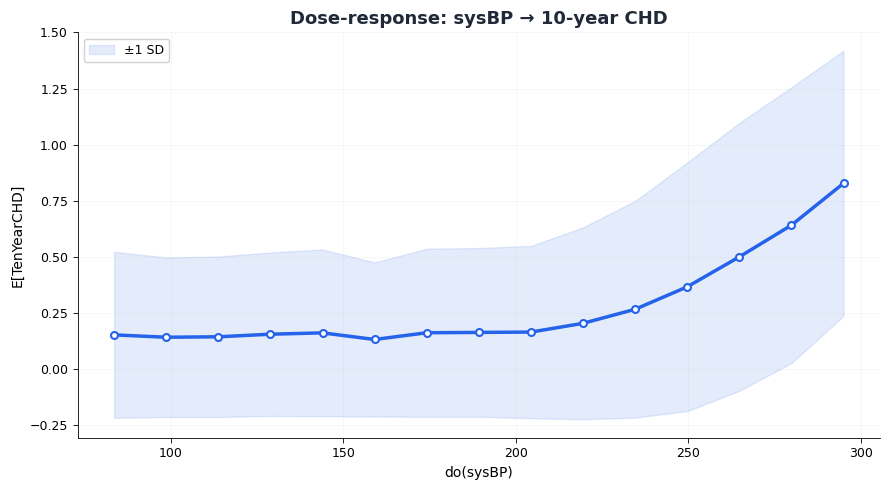

In [19]:
r_curve = model.run(cp.CausalEffectCurve(
    treatment='sysBP', outcome='TenYearCHD', n_points=15, num_samples=2000,
))
fig, _ = cp.plotting.plot_causal_effect_curve(r_curve, title='Dose-response: sysBP → 10-year CHD')
fig.savefig(FIGDIR / 'dose_response.pdf')

## 10. Anomaly attribution and distribution shift

`AnomalyAttribution` decomposes why the highest-risk patients have elevated CHD scores. `DistributionChange` attributes the CHD prevalence gap between younger and older subcohorts to specific upstream nodes.

In [20]:
young = df[df['age'] < 45]
old   = df[df['age'] >= 55]

r_anom, r_dist = model.run([
    cp.AnomalyAttribution(target='TenYearCHD', anomaly_threshold_percentile=95),
    cp.DistributionChange(target='TenYearCHD', old_data=young, new_data=old, num_samples=3000),
])
r_anom

Estimating conditional anomaly scores:   0%|          | 0/16 [00:00<?, ?it/s]

Estimating conditional anomaly scores:   6%|▋         | 1/16 [00:00<00:04,  3.26it/s]

Estimating conditional anomaly scores:  12%|█▎        | 2/16 [00:00<00:04,  3.33it/s]

Estimating conditional anomaly scores:  19%|█▉        | 3/16 [00:00<00:03,  3.36it/s]

Estimating conditional anomaly scores:  25%|██▌       | 4/16 [00:19<01:28,  7.36s/it]

...

Evaluating set functions...:  73%|███████▎  | 192/263 [00:02<00:01, 70.30it/s]

Evaluating set functions...:  85%|████████▌ | 224/263 [00:03<00:00, 69.40it/s]

Evaluating set functions...:  97%|█████████▋| 256/263 [00:03<00:00, 68.61it/s]

Evaluating set functions...: 100%|██████████| 263/263 [00:03<00:00, 75.01it/s]

               Anomaly Attribution Results                
 Target                                         TenYearCHD
 N Anomalies                                           216
----------------------------------------------------------
  TenYearCHD                                        1.8191
  sysBP                                             0.0050
  age                                               0.0035
  glucose                                           0.0025
  currentSmoker                                    -0.0012
  prevalentStroke                                  -0.0009
  male                                             -0.0009
  cigsPerDay                                        0.0006
  BMI                                               0.0005
  diabetes                                          0.0001
  totChol                                           0.0001
  heartRate                                        -0.0000
  education                                         0.00

In [21]:
r_dist

               Distribution Change Results                
 Target                                         TenYearCHD
 N Old                                               1,427
 N New                                               1,317
----------------------------------------------------------
  BMI                                               0.0000
  TenYearCHD                                        0.0000
  age                                               0.0000
  cigsPerDay                                        0.0000
  currentSmoker                                     0.0000
  diabetes                                          0.0000
  education                                         0.0000
  glucose                                           0.0000
  heartRate                                         0.0000
  male                                              0.0000
  prevalentStroke                                   0.0000
  sysBP                                             0.00

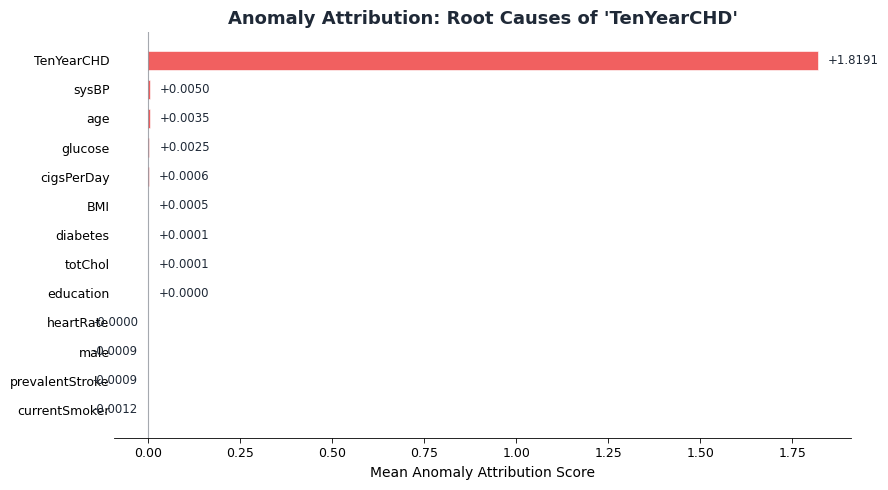

In [22]:
fig, _ = cp.plotting.plot_anomalies(r_anom)
fig.savefig(FIGDIR / 'anomalies.pdf')

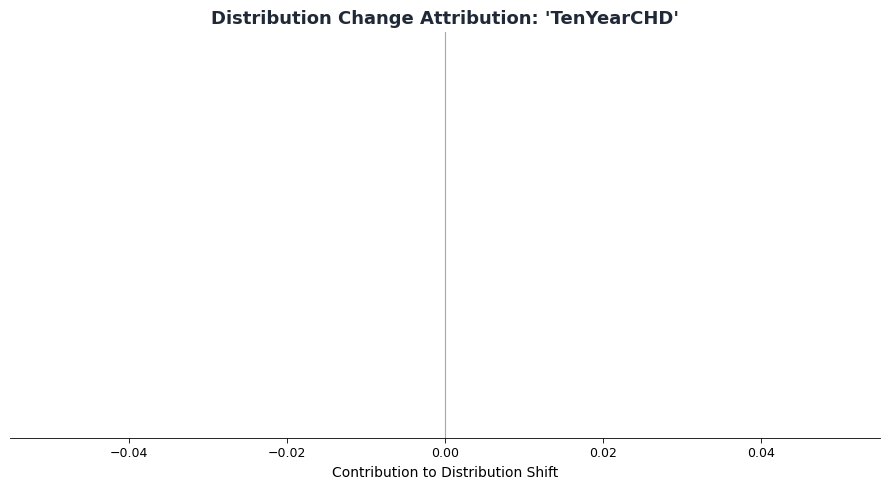

In [23]:
fig, _ = cp.plotting.plot_distribution_change(r_dist)
fig.savefig(FIGDIR / 'distribution_change.pdf')

## 11. Counterfactual fairness audit

Is the sex gap in CHD a *direct* causal effect or is it mediated by downstream risk factors? `FairnessAudit` answers exactly this question.

In [24]:
r_fair = model.run(cp.FairnessAudit(
    protected_attribute='male', outcome='TenYearCHD',
    privileged_value=1, unprivileged_value=0,
))
r_fair

                  Fairness Audit Results                  
 Protected Attribute                                  male
 Outcome                                        TenYearCHD
 N Privileged                                        1,820
 N Unprivileged                                      2,420
----------------------------------------------------------
 Counterfactual Disparity                           0.0040
 Observational Gap                                  0.0641
 Mean Individual Unfairness                         0.0040
 Max Individual Unfairness                          1.0000

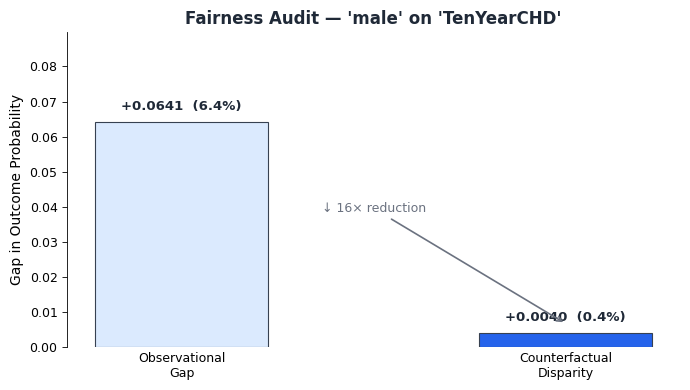

In [25]:
fig, _ = cp.plotting.plot_fairness_audit(r_fair)
fig.savefig(FIGDIR / 'fairness.pdf')

## 12. Sensitivity analysis

Re-estimate the smoking ATE under placebo, subset, and random-common-cause refutations to test robustness.

In [26]:
r_sens = model.run(cp.SensitivityAnalysis(
    treatment='currentSmoker', outcome='TenYearCHD',
    methods=['placebo', 'subset', 'random_common_cause'],
    num_simulations=5, num_samples=1000,
))
r_sens

Fitting causal models:   0%|          | 0/16 [00:00<?, ?it/s]

Fitting causal mechanism of node age:   0%|          | 0/16 [00:00<?, ?it/s]

Fitting causal mechanism of node male:   0%|          | 0/16 [00:00<?, ?it/s]

Fitting causal mechanism of node education:   0%|          | 0/16 [00:00<?, ?it/s]

Fitting causal mechanism of node currentSmoker:   0%|          | 0/16 [00:00<?, ?it/s]

...

Fitting causal mechanism of node TenYearCHD:  65%|██████▍   | 11/17 [00:00<00:00, 62.47it/s]     

Fitting causal mechanism of node BPMeds:  65%|██████▍   | 11/17 [00:00<00:00, 62.47it/s]    

Fitting causal mechanism of node _random_cause:  65%|██████▍   | 11/17 [00:00<00:00, 62.47it/s]

Fitting causal mechanism of node _random_cause: 100%|██████████| 17/17 [00:00<00:00, 84.56it/s]

               Sensitivity Analysis Results               
 Result                                          SENSITIVE
 Original ATE                                       0.0180
----------------------------------------------------------
 Placebo
    Mean Effect                                     0.0086
    Std Effect                                      0.0128
    P-value                                         0.2000
    Passed                                              No
----------------------------------------------------------
 Subset
    Mean Effect                                    -0.0086
    Std Effect                                      0.0141
    Fraction                                        0.8000
    Passed                                             Yes
----------------------------------------------------------
 Random Common Cause
    Mean Effect                                    -0.0008
    Std Effect                                      0.0201
    Passed        

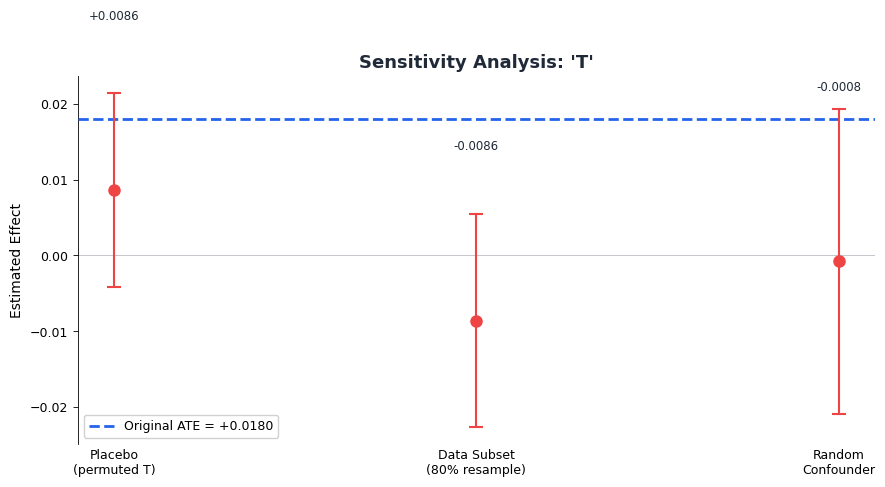

In [27]:
fig, _ = cp.plotting.plot_sensitivity(r_sens)
fig.savefig(FIGDIR / 'sensitivity.pdf')

## 13. Pipeline + Report

Everything above is also expressible as a single declarative pipeline. `cp.Pipeline` runs an arbitrary list of tasks, and `cp.Report` consolidates them into a paper-ready text summary.

In [28]:
pipe = cp.Pipeline(model)
pipe.run([
    cp.ATE(treatment='currentSmoker', outcome='TenYearCHD', num_samples=2000),
    cp.ArrowStrength(target='TenYearCHD'),
    cp.FairnessAudit(protected_attribute='male', outcome='TenYearCHD'),
])
print(cp.Report(model, pipe.results).to_text())

CausalPype Analysis Report

--- Causal Graph ---
  Nodes (16): ['age', 'male', 'education', 'currentSmoker', 'cigsPerDay', 'BMI', 'sysBP', 'diaBP', 'prevalentHyp', 'glucose', 'diabetes', 'totChol', 'heartRate', 'prevalentStroke', 'TenYearCHD', 'BPMeds']
  Edges (33): [('age', 'sysBP'), ('age', 'diaBP'), ('age', 'totChol'), ('age', 'glucose'), ('age', 'BMI'), ('age', 'heartRate'), ('age', 'TenYearCHD'), ('male', 'sysBP'), ('male', 'diaBP'), ('male', 'totChol'), ('male', 'BMI'), ('male', 'heartRate'), ('male', 'currentSmoker'), ('male', 'TenYearCHD'), ('education', 'currentSmoker'), ('currentSmoker', 'cigsPerDay'), ('cigsPerDay', 'heartRate'), ('cigsPerDay', 'TenYearCHD'), ('BMI', 'sysBP'), ('BMI', 'diaBP'), ('BMI', 'totChol'), ('BMI', 'glucose'), ('BMI', 'diabetes'), ('BMI', 'TenYearCHD'), ('sysBP', 'prevalentHyp'), ('sysBP', 'TenYearCHD'), ('diaBP', 'prevalentHyp'), ('prevalentHyp', 'BPMeds'), ('glucose', 'diabetes'), ('diabetes', 'TenYearCHD'), ('totChol', 'TenYearCHD'), ('heartRate',

---

**Recap.** Sections 4–12 each correspond to one of the 14 composable tasks in `causalpype.__all__`; section 13 shows the same tasks orchestrated as a `Pipeline` and rendered as a `Report`. Figures saved to `examples/figures/` are the ones referenced from the SETN2026 paper.